The goal of this notebook is to create a non-deep learning baseline model for classifying simplified level of fouling (SLoF) for a data set of underwater images.

In [2]:
import pandas as pd
import imageio.v2 as imageio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import skimage.measure
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

In [3]:
data_dir = 'data-biofouling/'
image_dir = 'data-biofouling/images/'
metadata_filename = 'metadata.csv'

In [4]:
# Loading the metadata csv file
df = pd.read_csv(data_dir + metadata_filename)

In [5]:
df.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training


In [6]:
# numerically encode categorical variables so that we can make a correlation matrix
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=["object", "category"]):
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [7]:
df_encoded.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,0,1,8,5,0,3,0
1,1,1,8,5,0,3,0
2,2,1,8,5,0,2,0
3,3,1,8,5,0,2,0
4,4,1,8,5,0,3,0


In [8]:
# Load all of the images
image_filenames = df['image.name']
images = {}
for filename in image_filenames:
    images[filename] = imageio.imread(image_dir + filename)

In [9]:
# Some ways to measure complexity of an image
# -shannon entropy, implemented in skimage.shannon_entropy
# -gradient_energy, implemented below
# -variance of red/green/blue channels

def gradient_energy(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    gx, gy = np.gradient(img.astype(float))
    return np.mean(np.sqrt(gx**2 + gy**2))

def laplacian_variance(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    lap = -4*img + np.roll(img, 1, 0) + np.roll(img, -1, 0) + np.roll(img, 1, 1) + np.roll(img, -1, 1)
    return lap.var()

def channel_variances(img):
    # (red, green, blue)
    variances = np.var(img, axis=(0, 1)) 
    return tuple(variances)

In [10]:
# make an enlarged dataframe including the complexity metrics

entropy_list = []
gradient_energy_list = []
laplacian_variance_list = []
red_variance_list = []
green_variance_list = []
blue_variance_list = []

timing = True
if timing:
    j = 0
    total = len(image_filenames)
    t_0 = time.time()

for filename in image_filenames:
    img = images[filename]
    entropy_list.append(skimage.measure.shannon_entropy(img))
    gradient_energy_list.append(gradient_energy(img))
    laplacian_variance_list.append(laplacian_variance(img))
    
    r_var, g_var, b_var = channel_variances(img)
    red_variance_list.append(r_var)
    green_variance_list.append(g_var)
    blue_variance_list.append(b_var)

    if timing:
        j += 1
        if j % 500 == 0:
            print(f"Processed image {j} of {total}")
            t_1 = time.time()
            time_elapsed = t_1 - t_0
            avg_time = time_elapsed / j
            print(f"\tTime spent:", int(time_elapsed), "seconds")
            print(f"\tEstimated time remaining:", int((total-j)*avg_time), 'seconds\n') 
   
df_aug = df.copy()
df_aug['entropy'] = entropy_list
df_aug['gradient_energy'] = gradient_energy_list
df_aug['laplacian_var'] = laplacian_variance_list
df_aug['red_var'] = red_variance_list
df_aug['green_var'] = green_variance_list
df_aug['blue_var'] = blue_variance_list

Processed image 500 of 10263
	Time spent: 41 seconds
	Estimated time remaining: 803 seconds

Processed image 1000 of 10263
	Time spent: 75 seconds
	Estimated time remaining: 699 seconds

Processed image 1500 of 10263
	Time spent: 112 seconds
	Estimated time remaining: 655 seconds

Processed image 2000 of 10263
	Time spent: 147 seconds
	Estimated time remaining: 609 seconds

Processed image 2500 of 10263
	Time spent: 181 seconds
	Estimated time remaining: 565 seconds

Processed image 3000 of 10263
	Time spent: 218 seconds
	Estimated time remaining: 528 seconds

Processed image 3500 of 10263
	Time spent: 255 seconds
	Estimated time remaining: 494 seconds

Processed image 4000 of 10263
	Time spent: 291 seconds
	Estimated time remaining: 456 seconds

Processed image 4500 of 10263
	Time spent: 328 seconds
	Estimated time remaining: 420 seconds

Processed image 5000 of 10263
	Time spent: 364 seconds
	Estimated time remaining: 384 seconds

Processed image 5500 of 10263
	Time spent: 401 second

In [11]:
df_aug.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split,entropy,gradient_energy,laplacian_var,red_var,green_var,blue_var
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training,7.210319,4.478048,636.869978,1167.255624,1246.322851,908.185944
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training,7.272785,5.438474,651.793542,1431.521255,1157.676356,896.145955
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training,6.754425,3.899760,672.922542,726.176904,2836.436721,3370.453269
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training,6.805911,3.346528,638.983190,1927.794439,800.957564,610.556934
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training,7.596727,5.017859,816.255540,3071.784278,4140.360718,4639.516300


In [12]:
df_train = df_aug[df_aug['split'] == 'training']
df_val = df_aug[df_aug['split'] == 'validation']

In [13]:
# Before we can set up the feature columns, we need to convert any non-numeric columns we want to use into numeric
# There should be no information from the image.name or dataset.name, so I'll just not include those as features
# The niche.area might be useful information, so I'll label encode that column
le = LabelEncoder()
df_train.loc[:, 'niche.area.numeric'] = le.fit_transform(df_train['niche.area'])
df_val.loc[:, 'niche.area.numeric'] = le.transform(df_val['niche.area'])

C:\Users\Joshua\AppData\Local\Temp\ipykernel_1432\3011477177.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:, 'niche.area.numeric'] = le.fit_transform(df_train['niche.area'])
C:\Users\Joshua\AppData\Local\Temp\ipykernel_1432\3011477177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val.loc[:, 'niche.area.numeric'] = le.transform(df_val['niche.area'])


In [14]:
df_train.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split,entropy,gradient_energy,laplacian_var,red_var,green_var,blue_var,niche.area.numeric
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training,7.210319,4.478048,636.869978,1167.255624,1246.322851,908.185944,5
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training,7.272785,5.438474,651.793542,1431.521255,1157.676356,896.145955,5
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training,6.754425,3.899760,672.922542,726.176904,2836.436721,3370.453269,5
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training,6.805911,3.346528,638.983190,1927.794439,800.957564,610.556934,5
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training,7.596727,5.017859,816.255540,3071.784278,4140.360718,4639.516300,5


In [15]:
# setting up x_train, x_val, y_train, y_val for various models
feature_columns = ['vessel.id','niche.area.numeric','paint.quality','entropy','gradient_energy','laplacian_var','red_var','green_var','blue_var']
x_train = df_train[feature_columns]
x_val = df_val[feature_columns]
y_train = df_train['SLoF']
y_val = df_val['SLoF']

Dummy accuracy: 0.5873959571938169
Dummy log loss: 14.87175710585452


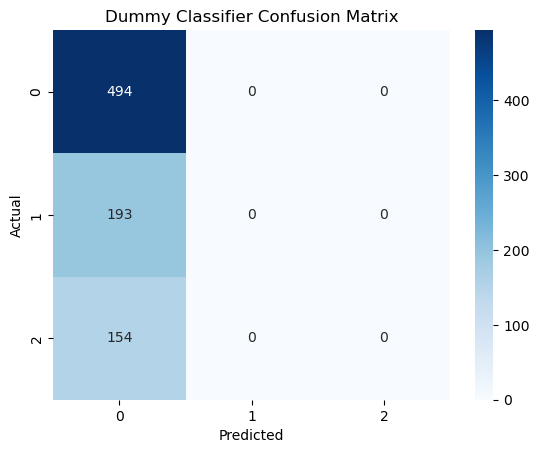

In [16]:
# make a dummy classifier for a baseline
dummy = DummyClassifier(strategy = 'most_frequent')
dummy.fit(x_train, y_train)
y_dummy_pred = dummy.predict(x_val)
y_dummy_prob = dummy.predict_proba(x_val)
print("Dummy accuracy:", accuracy_score(y_val, y_dummy_pred))
print("Dummy log loss:", log_loss(y_val, y_dummy_prob))
cm = confusion_matrix(y_val, y_dummy_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dummy Classifier Confusion Matrix")
plt.show()

Random forest accuracy: 0.6218787158145065
Random forest log loss: 0.7984063390006364


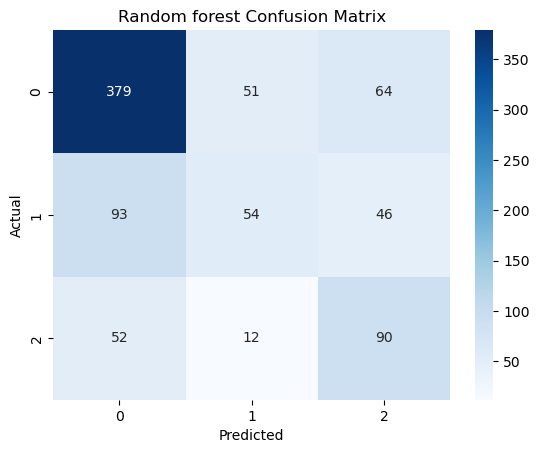

In [17]:
# make a random forest model, trying to improve on dummy classifier
rf = RandomForestClassifier(n_estimators = 500,
                            max_samples = 0.5, # for each tree, use half the rows to train that tree
                            max_features = 0.5, # for each tree, use half the columns to train that tree
                            max_depth = 10,
                            class_weight = 'balanced')
rf.fit(x_train,y_train)
y_rf_pred = rf.predict(x_val)
y_rf_prob = rf.predict_proba(x_val)
rf_loss = log_loss(y_val, y_rf_prob)
print("Random forest accuracy:", accuracy_score(y_val, y_rf_pred))
print("Random forest log loss:", log_loss(y_val, y_rf_prob))
cm = confusion_matrix(y_val, y_rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random forest Confusion Matrix")
plt.show()

In [18]:
# analyze the random forest for feature importance
importance = pd.Series(rf.feature_importances_, index=feature_columns)
importance = importance.sort_values(ascending=False)
print(importance)

paint.quality         0.204698
gradient_energy       0.146543
vessel.id             0.113661
laplacian_var         0.100713
red_var               0.099606
entropy               0.092565
blue_var              0.086080
green_var             0.085543
niche.area.numeric    0.070593
dtype: float64
